Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=140045725412064 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,No log,0.806777,0.666667,0.649821,0.698906,0.666667,0.154419,46.325669
2,No log,0.551382,0.760000,0.759997,0.761600,0.760000,0.104828,31.448440
3,1.537700,0.445776,0.806667,0.806885,0.807923,0.806667,0.086583,25.974956
4,1.537700,0.397733,0.833333,0.832602,0.832451,0.833333,0.075811,22.743398
5,1.537700,0.372304,0.856667,0.855889,0.856601,0.856667,0.070379,21.113671
6,0.615200,0.356873,0.873333,0.872798,0.873081,0.873333,0.066937,20.081197
7,0.615200,0.350275,0.880000,0.879704,0.879787,0.880000,0.064609,19.382769
8,0.334600,0.348503,0.873333,0.872768,0.872995,0.873333,0.063954,19.186102


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=13.33s tok/s=0.0 ex/s=0.00 peak_mem=5.07GiB lr=2.81e-05
[EVALUATION_PERFORMANCE] tokens=81920 time=0.55s tok/s=149366.3 ex/s=1166.92
[EVALUATION_PERFORMANCE] accuracy=0.6667 cost=$0.01 accuracy_per_$=83.44
[OPTIMIZER] epoch_start=1.0 global_step=19 wrapped=AcceleratedOptimizer base=AdamW lr=2.8098591549295775e-05 id=140045725412064 hyperparams={'lr': 2.8098591549295775e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 2.8098591549295775e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[2.8098591549295775e-05]
[PARAMS] 

[EVALUATION_PERFORMANCE] tokens=81920 time=0.55s tok/s=149170.5 ex/s=1165.39
[EVALUATION_PERFORMANCE] accuracy=0.9000 cost=$0.12 accuracy_per_$=7.23

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 8.0,
 'eval_accuracy': 0.9,
 'eval_f1_macro': 0.8997547514046015,
 'eval_loss': 0.32119321823120117,
 'eval_mse': 0.05808234570300503,
 'eval_precision_macro': 0.9015071748340255,
 'eval_recall_macro': 0.8999999999999999,
 'eval_runtime': 0.6265,
 'eval_samples_per_second': 478.869,
 'eval_sse': 17.424703710901507,
 'eval_steps_per_second': 7.981}


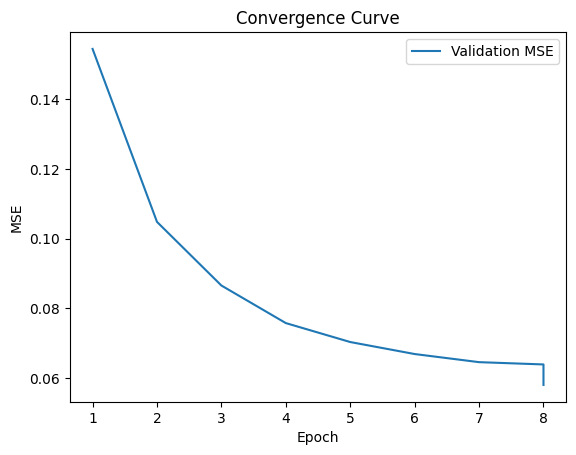

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

